# Evaluación del modelo y análisis del umbral de clasificación

## Objetivos de la sesión

En esta sesión se busca:

1. Retomar el modelo baseline de regresión logística.
2. Profundizar en la evaluación del clasificador.
3. Comparar distintas métricas de desempeño.
4. Analizar el efecto del umbral de clasificación sobre los resultados.
5. Comprender la diferencia entre predecir probabilidades y predecir clases.
6. Identificar fortalezas y limitaciones del modelo baseline.

## Contexto

En la sesión anterior se entrenó una regresión logística para predecir incumplimiento de pago. Sin embargo, evaluar un clasificador binario no consiste únicamente en calcular el accuracy.

En problemas de riesgo de crédito, distintas métricas pueden reflejar comportamientos muy diferentes del modelo, especialmente cuando las clases no están perfectamente balanceadas. Además, la decisión final depende del umbral que se utilice para convertir probabilidades en etiquetas de clase.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score
)

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")



## Carga del dataset limpio

En esta sección se carga la versión depurada del conjunto de datos preparada en sesiones anteriores.

Además, se verifica que la variable objetivo tenga el nombre `default_next_month` y, si es necesario, se reconstruye la variable `AGE_GROUP` para usarla como predictor categórico en el modelo.

In [2]:
df = pd.read_csv("default_credit_clean.csv")

if "default payment next month" in df.columns:
    df = df.rename(columns={"default payment next month": "default_next_month"})

if "AGE_GROUP" not in df.columns:
    bins = [20, 30, 40, 50, 60, 80]
    labels = ["20-29", "30-39", "40-49", "50-59", "60+"]
    df["AGE_GROUP"] = pd.cut(df["AGE"], bins=bins, labels=labels, right=False)

print("Dimensiones del dataset:", df.shape)
print("\nPrimeras columnas:")
print(df.columns.tolist()[:10])
df.head()

Dimensiones del dataset: (30000, 29)

Primeras columnas:
['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4']


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default_next_month,SEX_LABEL,EDUCATION_LABEL,MARRIAGE_LABEL,AGE_GROUP
0,1,20000,2,2,1,24,2,2,-1,-1,-2,-2,3913,3102,689,0,0,0,0,689,0,0,0,0,1,Femenino,Universidad,Casado,20-29
1,2,120000,2,2,2,26,-1,2,0,0,0,2,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000,1,Femenino,Universidad,Soltero,20-29
2,3,90000,2,2,2,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,0,Femenino,Universidad,Soltero,30-39
3,4,50000,2,2,1,37,0,0,0,0,0,0,46990,48233,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000,0,Femenino,Universidad,Casado,30-39
4,5,50000,1,2,1,57,-1,0,-1,0,0,0,8617,5670,35835,20940,19146,19131,2000,36681,10000,9000,689,679,0,Masculino,Universidad,Casado,50-59




El conjunto de datos se cargó correctamente y contiene **30,000 observaciones** y **29 variables**. Esto confirma que estamos trabajando con la base completa y que ya incluye algunas columnas auxiliares útiles, como:

- `SEX_LABEL`
- `EDUCATION_LABEL`
- `MARRIAGE_LABEL`
- `AGE_GROUP`

Además, se observa que la variable objetivo ya aparece con el nombre **`default_next_month`**, lo cual facilita su uso en el modelado.

Las primeras filas muestran que el dataset contiene:

- variables demográficas (`SEX`, `EDUCATION`, `MARRIAGE`, `AGE`),
- variables de historial de pago (`PAY_0`, `PAY_2`, ..., `PAY_6`),
- variables de facturación (`BILL_AMT1`, ..., `BILL_AMT6`),
- variables de pagos previos (`PAY_AMT1`, ..., `PAY_AMT6`),
- y la variable objetivo de incumplimiento.

Con esto, el conjunto de datos está listo para separar predictores y variable objetivo.

## Separación de predictores y variable objetivo

En esta sección se define:

- `X`: conjunto de variables predictoras,
- `y`: variable objetivo `default_next_month`.

Además, se excluyen columnas que no deben entrar directamente al modelo, como:

- el identificador `ID`,
- y las etiquetas de texto auxiliares (`SEX_LABEL`, `EDUCATION_LABEL`, `MARRIAGE_LABEL`).

Estas columnas son útiles para interpretación, pero no para el ajuste del modelo.

In [3]:
cols_to_drop = ["default_next_month"]
optional_drop = ["ID", "SEX_LABEL", "EDUCATION_LABEL", "MARRIAGE_LABEL"]

for col in optional_drop:
    if col in df.columns:
        cols_to_drop.append(col)

X = df.drop(columns=cols_to_drop)
y = df["default_next_month"]

print("Dimensiones de X:", X.shape)
print("Dimensiones de y:", y.shape)
print("\nColumnas de X:")
print(X.columns.tolist())

Dimensiones de X: (30000, 24)
Dimensiones de y: (30000,)

Columnas de X:
['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'AGE_GROUP']


La matriz de predictores `X` quedó formada por **24 variables**, mientras que `y` contiene la variable objetivo `default_next_month` para las **30,000 observaciones**.

Las variables predictoras incluyen:

- variables demográficas: `LIMIT_BAL`, `SEX`, `EDUCATION`, `MARRIAGE`, `AGE`,
- historial de pagos: `PAY_0`, `PAY_2`, ..., `PAY_6`,
- montos de facturación: `BILL_AMT1`, ..., `BILL_AMT6`,
- montos de pago: `PAY_AMT1`, ..., `PAY_AMT6`,
- y la variable categórica `AGE_GROUP`.

Se excluyeron correctamente:

- `default_next_month`, por ser la variable respuesta,
- `ID`, por ser sólo un identificador,
- y las columnas auxiliares de etiquetas, ya que no deben entrar directamente al modelo.

Con esto, ya está definida la estructura básica para entrenar y evaluar el clasificador.

## Distribución de la variable objetivo

Antes de entrenar o evaluar el modelo, conviene revisar cómo se distribuyen las clases de la variable objetivo.

Esto permite identificar si el problema está balanceado o desbalanceado, lo cual es importante porque puede afectar la interpretación de métricas como `accuracy`, `precision` y `recall`.

In [4]:
target_dist = y.value_counts().sort_index().to_frame("count")
target_dist["proportion"] = y.value_counts(normalize=True).sort_index()
target_dist

,count,proportion
default_next_month,,
0,23364,0.7788
1,6636,0.2212



La variable objetivo presenta dos clases:

- **0 = no incumplimiento:** 23,364 casos (**77.88%**)
- **1 = incumplimiento:** 6,636 casos (**22.12%**)

Esto muestra que el problema está **desbalanceado**, ya que la mayoría de las observaciones corresponde a clientes que **no incumplieron**. Aunque la clase positiva no es extremadamente rara, sí es claramente minoritaria.

Este punto es importante porque, en conjuntos desbalanceados, una métrica como el **accuracy** puede dar una impresión demasiado optimista del modelo. Por ello, en esta sesión será necesario revisar también otras métricas, como:

- **precision**,
- **recall**,
- **F1-score**,
- y **ROC-AUC**.

En particular, como el interés del problema está en detectar clientes con riesgo de incumplimiento, será fundamental observar qué tan bien identifica el modelo la clase `1`.

## Visualización de la variable objetivo

Además de la tabla de frecuencias, es útil visualizar la distribución de la variable objetivo mediante una gráfica de barras.

Esto permite apreciar de forma más inmediata el desbalance entre las clases.

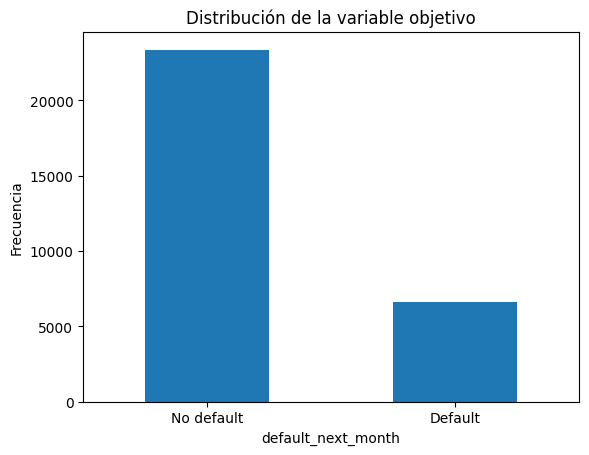

In [5]:
y.value_counts().sort_index().plot(kind="bar")
plt.xticks([0, 1], ["No default", "Default"], rotation=0)
plt.ylabel("Frecuencia")
plt.title("Distribución de la variable objetivo")
plt.show()



La gráfica de barras confirma visualmente lo observado en la tabla de frecuencias: la clase **No default** es claramente mayoritaria, mientras que la clase **Default** representa una fracción menor del total de observaciones.

Esto refuerza la idea de que estamos ante un problema de **clasificación desbalanceada**. En consecuencia, no será suficiente evaluar el modelo únicamente con `accuracy`, ya que un clasificador podría obtener un valor relativamente alto simplemente favoreciendo la clase mayoritaria.

Por ello, en las siguientes etapas será importante analizar métricas que reflejen mejor la capacidad del modelo para identificar a los clientes que sí incumplen, especialmente:

- **recall**, para medir qué proporción de incumplimientos reales logra detectar,
- **precision**, para evaluar qué tan confiables son las predicciones positivas,
- y **F1-score**, que combina ambas.

## División en entrenamiento y prueba

Para evaluar adecuadamente el modelo, se divide el conjunto de datos en dos partes:

- **entrenamiento**, que se utilizará para ajustar la regresión logística;
- **prueba**, que se utilizará para evaluar su desempeño en datos no vistos.

Además, se usará una partición **estratificada**, de modo que la proporción de clientes con y sin incumplimiento se conserve aproximadamente en ambos subconjuntos.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

print("\nProporción de incumplimiento en y_train:", y_train.mean())
print("Proporción de incumplimiento en y_test :", y_test.mean())

X_train: (24000, 24)
X_test : (6000, 24)
y_train: (24000,)
y_test : (6000,)

Proporción de incumplimiento en y_train: 0.22120833333333334
Proporción de incumplimiento en y_test : 0.22116666666666668




La partición se realizó correctamente:

- **24,000 observaciones** se asignaron al conjunto de entrenamiento,
- **6,000 observaciones** se reservaron para el conjunto de prueba.

Además, la proporción de incumplimiento se conservó prácticamente igual en ambos subconjuntos:

- en `y_train`: aproximadamente **22.12%**,
- en `y_test`: aproximadamente **22.12%**.

Esto confirma que la partición **estratificada** funcionó correctamente. Mantener la misma proporción de clases en entrenamiento y prueba es importante porque permite evaluar el modelo en condiciones representativas del conjunto original.

Con esto, ya se cuenta con una separación adecuada para entrenar el modelo y luego medir su desempeño en datos no vistos.

## Identificación de variables numéricas y categóricas

Antes de construir el pipeline de preprocesamiento, es necesario distinguir qué variables serán tratadas como:

- **categóricas**, que se codificarán con `one-hot encoding`,
- **numéricas**, que se imputarán y escalarán.

En esta sesión se considerarán como categóricas:

- `SEX`
- `EDUCATION`
- `MARRIAGE`
- `AGE_GROUP`

El resto de las variables se tratarán como numéricas.

In [7]:
categorical_features = ["SEX", "EDUCATION", "MARRIAGE", "AGE_GROUP"]
categorical_features = [col for col in categorical_features if col in X_train.columns]

numeric_features = [col for col in X_train.columns if col not in categorical_features]

print("Variables categóricas:")
print(categorical_features)

print("\nNúmero de variables categóricas:", len(categorical_features))

print("\nVariables numéricas:")
print(numeric_features)

print("\nNúmero de variables numéricas:", len(numeric_features))

Variables categóricas:
['SEX', 'EDUCATION', 'MARRIAGE', 'AGE_GROUP']

Número de variables categóricas: 4

Variables numéricas:
['LIMIT_BAL', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']

Número de variables numéricas: 20




Se clasificaron las variables predictoras en dos grupos:

### Variables categóricas
- `SEX`
- `EDUCATION`
- `MARRIAGE`
- `AGE_GROUP`

Estas variables serán transformadas mediante **codificación one-hot**, ya que representan categorías y no deben tratarse como cantidades continuas en el modelo.

### Variables numéricas
Las otras **20 variables** se tratarán como numéricas, incluyendo:

- variables financieras como `LIMIT_BAL`,
- historial de pagos como `PAY_0`, `PAY_2`, ..., `PAY_6`,
- montos facturados `BILL_AMT1` a `BILL_AMT6`,
- y montos pagados `PAY_AMT1` a `PAY_AMT6`.

Esta separación es importante porque cada tipo de variable requiere un tratamiento distinto dentro del pipeline de preprocesamiento. Con ello se busca que el modelo reciba la información en un formato adecuado para el ajuste y la predicción.

## Construcción del preprocesamiento

Se definirá un pipeline de preprocesamiento con dos ramas:

- para variables **numéricas**:
  - imputación de valores faltantes con la mediana,
  - escalamiento estandarizado;

- para variables **categóricas**:
  - imputación con la categoría más frecuente,
  - codificación `one-hot`.

Esto permite integrar todo el flujo de preparación de datos dentro del mismo modelo, evitando fugas de información y facilitando la reproducibilidad.

In [9]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(drop="first", handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `



El objeto `ColumnTransformer` se definió correctamente y muestra dos rutas de transformación claramente diferenciadas:

### Para variables numéricas
Se aplicará un pipeline con dos pasos:

1. **Imputación por mediana** (`SimpleImputer(strategy="median")`), en caso de que existan valores faltantes.
2. **Escalamiento estandarizado** (`StandardScaler()`), para que las variables numéricas queden en una escala comparable.

Esto es especialmente útil en regresión logística, ya que variables como `LIMIT_BAL`, `BILL_AMT*` y `PAY_AMT*` pueden tener magnitudes muy distintas.

### Para variables categóricas
Se aplicará otro pipeline con:

1. **Imputación por la categoría más frecuente**,
2. **Codificación one-hot** (`OneHotEncoder`), eliminando la primera categoría con `drop="first"` para evitar redundancia lineal innecesaria.

Este preprocesamiento permitirá que el modelo reciba las variables en un formato adecuado, respetando su naturaleza numérica o categórica. Además, al integrarlo en un solo objeto, el flujo de trabajo queda ordenado y reproducible.

## Construcción y entrenamiento del modelo baseline

En esta sección se arma un pipeline completo que integra:

- el preprocesamiento definido anteriormente,
- y el modelo de **regresión logística**.

Después, el modelo se ajustará usando el conjunto de entrenamiento.

In [10]:
log_reg = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=2000, random_state=42))
])

log_reg.fit(X_train, y_train)

print("Modelo entrenado correctamente.")

Modelo entrenado correctamente.




La regresión logística se entrenó correctamente sobre el conjunto de entrenamiento. Esto indica que el pipeline completo funcionó sin problemas, integrando:

- el preprocesamiento de variables numéricas y categóricas,
- y el ajuste del modelo de clasificación binaria.

En esta etapa ya se cuenta con un **modelo baseline** listo para generar:

- predicciones de clase,
- y probabilidades estimadas de incumplimiento.

A partir de aquí, el siguiente paso será evaluar su desempeño en el conjunto de prueba y analizar qué tan bien distingue entre clientes con y sin incumplimiento.

In [11]:
y_proba = log_reg.predict_proba(X_test)[:, 1]
y_pred_05 = (y_proba >= 0.5).astype(int)

print("Primeras 10 probabilidades predichas:")
print(y_proba[:10])

print("\nPrimeras 10 clases predichas con threshold = 0.5:")
print(y_pred_05[:10])

Primeras 10 probabilidades predichas:
[0.10926356 0.11588521 0.22234339 0.09644952 0.02987067 0.20598164
 0.12998139 0.15839348 0.07766285 0.19913152]

Primeras 10 clases predichas con threshold = 0.5:
[0 0 0 0 0 0 0 0 0 0]



Las primeras probabilidades estimadas por la regresión logística son todas **menores que 0.5**, por lo que, al aplicar el umbral estándar, el modelo clasifica esos primeros 10 casos como **`0 = no incumplimiento`**.

Esto ilustra una idea importante:

- la regresión logística primero produce una **probabilidad**,
- y sólo después esa probabilidad se transforma en una **clase** usando un umbral.

En este caso, como ninguna de las probabilidades iniciales supera 0.5, no aparece ninguna predicción positiva en esos primeros ejemplos. Esto no significa que el modelo nunca prediga incumplimiento, sino que para esas observaciones concretas el riesgo estimado no fue suficientemente alto bajo el criterio estándar.

Este comportamiento será importante al analizar más adelante si el umbral de 0.5 es adecuado o si conviene ajustar el punto de corte para detectar mejor a los clientes con mayor riesgo.

In [12]:
def evaluar_umbral(y_true, y_scores, threshold=0.5):
    y_pred = (y_scores >= threshold).astype(int)
    
    return {
        "threshold": threshold,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_scores)
    }

metricas_05 = evaluar_umbral(y_test, y_proba, threshold=0.5)
pd.DataFrame(metricas_05, index=["Logistic Regression"]).T

,Logistic Regression
threshold,0.5000
accuracy,0.8085
precision,0.6894
recall,0.2442
f1,0.3606
roc_auc,0.7101


Con el umbral estándar de **0.5**, la regresión logística presenta los siguientes resultados:

- **Accuracy = 0.8085**
- **Precision = 0.6894**
- **Recall = 0.2442**
- **F1-score = 0.3606**
- **ROC-AUC = 0.7101**

Estos resultados muestran un comportamiento mixto del modelo:

- El **accuracy** es relativamente alto (**80.85%**), pero esta métrica debe interpretarse con cuidado debido al desbalance de clases.
- La **precision** es también relativamente alta (**68.94%**), lo que significa que cuando el modelo predice incumplimiento, suele acertar en una proporción considerable de casos.
- Sin embargo, el **recall** es bajo (**24.42%**), lo que indica que el modelo está detectando sólo una fracción pequeña de los incumplimientos reales.
- Como consecuencia, el **F1-score** también es moderado-bajo (**0.3606**), ya que resume el compromiso entre precision y recall.
- El valor de **ROC-AUC = 0.7101** sugiere que el modelo sí tiene una capacidad discriminante razonable, es decir, distingue mejor que el azar entre clientes con y sin incumplimiento.

En conjunto, estos resultados sugieren que con umbral 0.5 el modelo es **conservador**: cuando predice incumplimiento suele tener razón, pero deja pasar muchos casos positivos reales. Por eso será importante revisar la matriz de confusión y después analizar qué ocurre al modificar el umbral de clasificación.

## Matriz de confusión con umbral 0.5

La matriz de confusión resume cómo se distribuyen los aciertos y errores del modelo al clasificar observaciones del conjunto de prueba.

En particular, permite distinguir entre:

- **verdaderos negativos**,
- **falsos positivos**,
- **falsos negativos**,
- **verdaderos positivos**.

Esto ayuda a entender con más detalle el comportamiento del clasificador, especialmente en un problema desbalanceado como éste.

In [14]:
cm_05 = confusion_matrix(y_test, y_pred_05)
cm_05_df = pd.DataFrame(
    cm_05,
    index=["Real: No default", "Real: Default"],
    columns=["Pred: No default", "Pred: Default"]
)

cm_05_df

,Pred: No default,Pred: Default
Real: No default,4527,146
Real: Default,1003,324


La matriz de confusión muestra con detalle cómo se comporta el modelo en el conjunto de prueba:

- **Verdaderos negativos (4527):** clientes que realmente no incumplieron y fueron clasificados correctamente como `No default`.
- **Falsos positivos (146):** clientes que en realidad no incumplieron, pero el modelo los clasificó como `Default`.
- **Falsos negativos (1003):** clientes que sí incumplieron, pero el modelo no los detectó.
- **Verdaderos positivos (324):** clientes que sí incumplieron y fueron identificados correctamente.

Esto confirma lo que ya sugerían las métricas:

- el modelo **acierta muy bien en la clase mayoritaria** (`No default`),
- pero **deja escapar muchos casos reales de incumplimiento**.

En particular, el número de **falsos negativos** es considerablemente mayor que el de **verdaderos positivos**, lo cual explica el valor bajo de `recall`. Es decir, con umbral 0.5 el modelo es bastante conservador: predice pocos incumplimientos y, aunque varios de ellos son correctos, no logra capturar una gran parte de los clientes que realmente incumplen.

Por eso será importante analizar qué ocurre al modificar el umbral de clasificación.

## Visualización de la matriz de confusión

Para complementar la tabla anterior, se representa la matriz de confusión mediante un mapa de calor. Esto facilita identificar visualmente dónde se concentran los aciertos y errores del modelo.

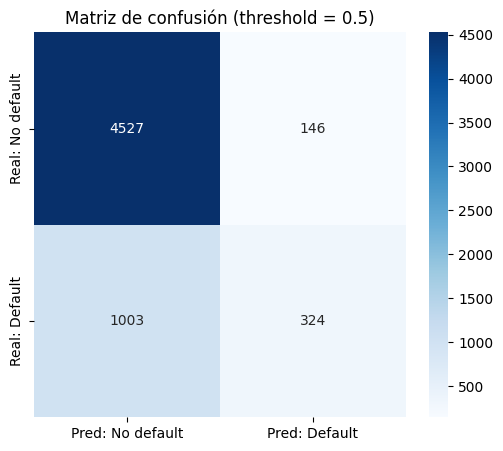

In [16]:
plt.figure(figsize=(6, 5))
sns.heatmap(cm_05_df, annot=True, fmt="d", cmap="Blues")
plt.title("Matriz de confusión (threshold = 0.5)")
plt.show()


El mapa de calor permite ver con mayor claridad que la mayor concentración de predicciones se encuentra en la celda de **verdaderos negativos**, lo cual refleja que el modelo identifica bien a muchos clientes que no incumplen.

Sin embargo, también destaca visualmente la celda de **falsos negativos**, que es considerablemente más grande que la de **verdaderos positivos**. Esto confirma que, con umbral 0.5, el modelo deja sin detectar una cantidad importante de clientes que sí incumplen.

En otras palabras, la representación gráfica refuerza la conclusión de que el clasificador está sesgado hacia la clase mayoritaria y que el umbral actual podría ser demasiado alto si el objetivo es detectar más casos de incumplimiento.

## Curva ROC

La curva ROC permite evaluar la capacidad discriminante del modelo a través de distintos umbrales de clasificación.

En esta gráfica se representa:

- en el eje horizontal, la tasa de falsos positivos,
- en el eje vertical, la tasa de verdaderos positivos.

Además, se calcula el valor de **ROC-AUC**, que resume la capacidad del modelo para distinguir entre clientes con y sin incumplimiento.

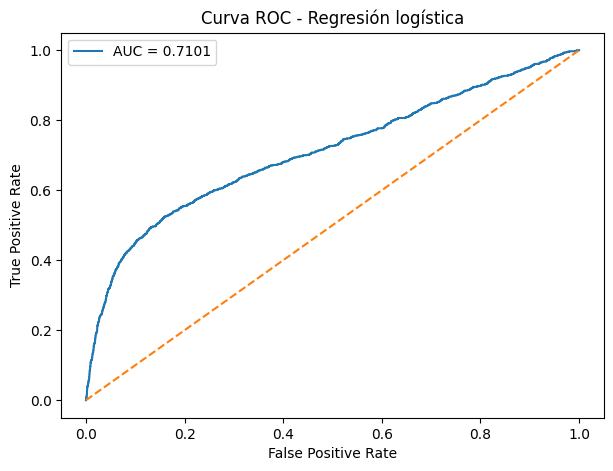

In [17]:
fpr, tpr, thresholds_roc = roc_curve(y_test, y_proba)
auc_score = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC - Regresión logística")
plt.legend()
plt.show()



La curva ROC se encuentra claramente por encima de la diagonal de referencia, lo cual indica que la regresión logística tiene una capacidad de discriminación **mejor que el azar** para distinguir entre clientes con y sin incumplimiento.

El valor de **AUC = 0.7101** confirma esta idea: el modelo posee una capacidad discriminante **razonable**, aunque todavía lejos de un desempeño excelente. En términos prácticos, esto significa que, al comparar un cliente que incumplió con uno que no incumplió, el modelo asigna una probabilidad mayor al cliente incumplido en una proporción apreciable de los casos.

Esta gráfica también sugiere que el problema no está en que el modelo no separe las clases, sino en que el umbral de decisión de **0.5** puede estar siendo demasiado estricto para detectar más incumplimientos. Por eso, el siguiente paso será revisar cómo se comporta el modelo al modificar el umbral de clasificación.

## Curva Precision-Recall

Además de la curva ROC, en problemas de clasificación desbalanceada es muy útil analizar la curva **Precision-Recall**.

Esta gráfica muestra cómo cambia el equilibrio entre:

- **precision**: qué tan confiables son las predicciones positivas,
- **recall**: qué proporción de incumplimientos reales logra detectar el modelo.

También se calculará el valor de **Average Precision (AP)** como resumen global de esta curva.

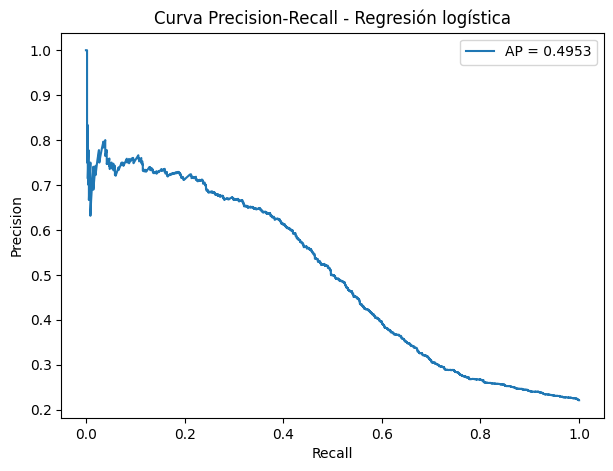

In [18]:
precision, recall, thresholds_pr = precision_recall_curve(y_test, y_proba)
ap_score = average_precision_score(y_test, y_proba)

plt.figure(figsize=(7, 5))
plt.plot(recall, precision, label=f"AP = {ap_score:.4f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Curva Precision-Recall - Regresión logística")
plt.legend()
plt.show()



La curva Precision-Recall muestra con mayor detalle el equilibrio entre **precision** y **recall** en un problema donde la clase positiva es minoritaria.

El valor de **Average Precision (AP) = 0.4953** indica que el modelo tiene una capacidad moderada para priorizar correctamente a los clientes con incumplimiento. Este valor es claramente mejor que la proporción base de la clase positiva, pero todavía deja margen importante de mejora.

La forma de la curva sugiere que:

- cuando se busca una **precision alta**, el modelo sólo logra detectar una fracción reducida de los incumplimientos;
- conforme se intenta aumentar el **recall**, la **precision** disminuye de manera gradual.

Esto confirma que existe un compromiso natural entre ambas métricas: detectar más incumplimientos suele implicar aceptar un mayor número de falsas alarmas. Por ello, el análisis del umbral de clasificación será importante para decidir qué equilibrio resulta más conveniente en el contexto del riesgo crediticio.

## Comparación de distintos umbrales de clasificación

Ahora se evaluará el modelo usando varios valores de umbral distintos a `0.5`.

El objetivo es observar cómo cambian las métricas cuando el clasificador se vuelve:

- más **sensible** a detectar incumplimientos (umbral más bajo),
- o más **conservador** al etiquetar un cliente como riesgoso (umbral más alto).

In [21]:
thresholds_to_test = [0.2, 0.3, 0.4, 0.5, 0.6]

resultados_umbral = pd.DataFrame([
    evaluar_umbral(y_test, y_proba, threshold=t)
    for t in thresholds_to_test
])

resultados_umbral

,threshold,accuracy,precision,recall,f1,roc_auc
0,0.2000,0.6083,0.3207,0.6895,0.4378,0.7101
1,0.3000,0.7992,0.5560,0.4567,0.5014,0.7101
2,0.4000,0.8133,0.6302,0.3775,0.4722,0.7101
3,0.5000,0.8085,0.6894,0.2442,0.3606,0.7101
4,0.6000,0.7960,0.7309,0.1228,0.2103,0.7101



La tabla muestra con claridad cómo cambia el comportamiento del modelo al modificar el umbral de decisión.

### Umbral 0.2
- **Recall = 0.6895**: el modelo detecta una proporción mucho mayor de incumplimientos reales.
- **Precision = 0.3207**: sin embargo, muchas de esas predicciones positivas son incorrectas.
- **Accuracy = 0.6083**: disminuye de forma importante.

Esto indica que con un umbral bajo el modelo se vuelve **más sensible**, pero también genera más falsas alarmas.

### Umbral 0.3
- **Recall = 0.4567**
- **Precision = 0.5560**
- **F1 = 0.5014**

Aquí se observa un equilibrio más razonable entre detectar incumplimientos y mantener una precisión aceptable. De hecho, este umbral presenta el **mejor F1-score** entre los valores probados, lo que sugiere un balance más adecuado entre `precision` y `recall`.

### Umbral 0.4 y 0.5
Al subir el umbral:
- la **precision** aumenta,
- pero el **recall** cae.

Por ejemplo, con `0.5`, el modelo alcanza **precision = 0.6894**, pero sólo detecta **24.42%** de los incumplimientos reales.

### Umbral 0.6
- **Precision = 0.7309**
- **Recall = 0.1228**

Este umbral hace al modelo muy conservador: cuando predice incumplimiento suele acertar, pero deja escapar la gran mayoría de los casos positivos.

### Observación importante
El valor de **ROC-AUC = 0.7101** permanece constante en todos los casos porque esta métrica depende de las probabilidades estimadas, no del umbral específico elegido.

En conjunto, estos resultados muestran que el umbral de clasificación tiene un efecto directo sobre el tipo de errores que comete el modelo. Si el interés principal es detectar más clientes con riesgo de incumplimiento, podría convenir un umbral menor que 0.5. En cambio, si se desea ser más estricto al etiquetar clientes como riesgosos, un umbral mayor produce más precision, pero a costa de perder muchos incumplimientos reales.

## Visualización de métricas según el umbral

Para apreciar mejor el efecto del umbral de clasificación, se construirá una gráfica donde se comparen varias métricas del modelo en función del punto de corte utilizado.

Esto permitirá ver de manera más clara el compromiso entre:

- **precision**,
- **recall**,
- **F1-score**,
- y **accuracy**.

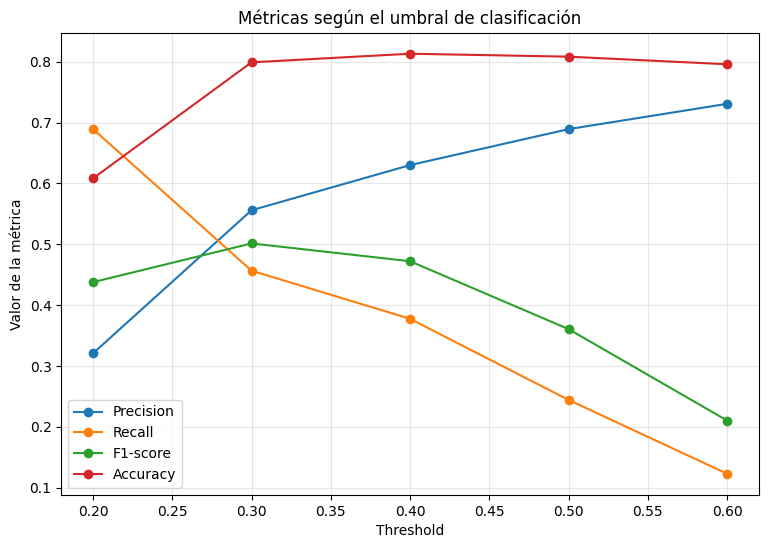

In [22]:
plt.figure(figsize=(9, 6))
plt.plot(resultados_umbral["threshold"], resultados_umbral["precision"], marker="o", label="Precision")
plt.plot(resultados_umbral["threshold"], resultados_umbral["recall"], marker="o", label="Recall")
plt.plot(resultados_umbral["threshold"], resultados_umbral["f1"], marker="o", label="F1-score")
plt.plot(resultados_umbral["threshold"], resultados_umbral["accuracy"], marker="o", label="Accuracy")

plt.xlabel("Threshold")
plt.ylabel("Valor de la métrica")
plt.title("Métricas según el umbral de clasificación")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()



La gráfica permite ver con claridad el efecto del umbral de clasificación sobre el desempeño del modelo.

Se observan los siguientes patrones:

- **Precision** aumenta conforme el umbral sube. Esto significa que, cuando el modelo se vuelve más estricto para predecir incumplimiento, las predicciones positivas tienden a ser más confiables.
- **Recall** disminuye al aumentar el umbral. Es decir, un criterio más estricto hace que el modelo detecte menos incumplimientos reales.
- El **F1-score** alcanza su valor más alto alrededor de **0.3**, lo que sugiere que ese umbral logra el mejor equilibrio entre `precision` y `recall` entre los casos probados.
- El **accuracy** permanece relativamente alto en casi todos los umbrales, con su mejor valor cerca de **0.4**, aunque esta métrica no refleja por sí sola la capacidad del modelo para detectar la clase minoritaria.

En conjunto, la gráfica refuerza una idea fundamental: **no existe un único umbral óptimo universal**. La elección depende del objetivo del problema:

- si interesa detectar más incumplimientos, conviene un umbral más bajo;
- si interesa que las predicciones positivas sean más seguras, conviene un umbral más alto.

Para este caso, si se busca un compromiso razonable entre detectar incumplimientos y mantener precisión aceptable, el umbral **0.3** parece ser una opción prometedora.

## Ejemplos de probabilidades predichas

Para cerrar la sesión, se construirá una tabla sencilla con algunas observaciones del conjunto de prueba, mostrando:

- la clase real,
- la probabilidad estimada de incumplimiento,
- y la clase predicha con umbral 0.5.

Esto ayuda a interpretar de manera más concreta qué significa una salida probabilística del modelo.

In [25]:
resultados = X_test.copy()
resultados["y_real"] = y_test.values
resultados["prob_default"] = y_proba
resultados["pred_0.5"] = y_pred_05

resultados[["y_real", "prob_default", "pred_0.5"]].head(15)

,y_real,prob_default,pred_0.5
6907,0,0.1093,0
24575,0,0.1159,0
26766,0,0.2223,0
2156,1,0.0964,0
3179,0,0.0299,0
29382,0,0.2060,0
24454,0,0.1300,0
23886,0,0.1584,0
5504,0,0.0777,0
29720,0,0.1991,0



La tabla muestra de forma concreta cómo debe interpretarse la salida del modelo:

- `y_real` indica la clase verdadera,
- `prob_default` representa la probabilidad estimada de incumplimiento,
- `pred_0.5` es la clase predicha usando el umbral estándar de 0.5.

En estos primeros ejemplos, todas las probabilidades son menores que **0.5**, por lo que el modelo predice **`0 = no incumplimiento`** en todos los casos mostrados. Sin embargo, se observa que hay algunos registros con `y_real = 1`, es decir, clientes que sí incumplieron pero que recibieron una probabilidad baja y por tanto fueron clasificados como no incumplidos.

Esto ilustra directamente el problema ya detectado en la matriz de confusión: con umbral 0.5, el modelo deja escapar varios casos positivos reales. En otras palabras, aunque las probabilidades generadas por la regresión logística tienen capacidad discriminante, el punto de corte utilizado puede ser demasiado alto si el objetivo es detectar más clientes en riesgo.

Por ello, el análisis de probabilidades refuerza la conveniencia de considerar umbrales alternativos, como **0.3**, que en esta sesión mostró un equilibrio más favorable entre `precision` y `recall`.

## Conclusiones de la cuarta sesión

En esta sesión se profundizó en la evaluación del modelo baseline de regresión logística.

Los principales resultados fueron los siguientes:

1. La variable objetivo presenta un **desbalance de clases**, con aproximadamente **77.88%** de casos sin incumplimiento y **22.12%** de casos con incumplimiento.
2. Con umbral **0.5**, el modelo alcanza un **accuracy** relativamente alto, pero su **recall** es bajo, lo que significa que detecta sólo una fracción limitada de los incumplimientos reales.
3. La matriz de confusión mostró que el modelo comete una cantidad considerable de **falsos negativos**, es decir, clientes que sí incumplen pero que no son identificados.
4. La **curva ROC** y el valor de **AUC = 0.7101** indican que el modelo tiene una capacidad discriminante razonable.
5. La **curva Precision-Recall** confirmó que existe un compromiso importante entre detectar más incumplimientos y mantener la confiabilidad de las predicciones positivas.
6. Al comparar distintos umbrales, se observó que el valor **0.3** ofrece un equilibrio más favorable entre `precision` y `recall` que el umbral estándar de **0.5**.

En conjunto, esta sesión mostró que evaluar un clasificador binario no consiste únicamente en revisar el `accuracy`. En problemas de riesgo de crédito, la elección del umbral de clasificación es una decisión importante, ya que determina el tipo de errores que el modelo comete y el equilibrio entre detectar más clientes en riesgo y evitar falsas alarmas.

## Tarea 4

Evaluar la regresión logística con los umbrales `0.3`, `0.5` y `0.6`, comparar `precision`, `recall` y `F1-score`, y escribir una conclusión breve indicando cuál umbral recomendaría y por qué.